In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scanpy.external as sce

In [2]:
import session_info
session_info.show()

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  mod_version = _find_version(mod.__version__)
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [3]:
sc.settings.set_figure_params(dpi=80)

# Read in adata

In [4]:
objects_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium'
path_adata = f'{objects_dir}/TACCO/tacco-splitted_filtered_raw.h5ad'
adata = sc.read_h5ad(path_adata)
adata

AnnData object with n_obs × n_vars = 333364 × 5001
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'tissue_block_id', 'celltypist_coarse', 'conf_score_coarse', 'celltypist_coarse_fin', 'celltypist_coarse2midmod', 'conf_score_coarse2midmod', 'celltypist_mid_fin', 'celltypist_midmod2fine', 'conf_score_midmod2fine', 'pca_harmony_leiden_0.2', 'pca_harmony_leiden_0.3', 'pca_harmony_leiden_0.4', 'pca_harmony_leiden_0.5', 'pca_harmony_leiden_0.8', 'pca_harmony_leiden_1.0', 'pca_harmony_leiden_1.5', 'pca_harmony_leiden_2.0', 'pca_harmony_leiden_

In [5]:
os.getcwd()

'/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/Xenium/5K/C194_Hst45/CamU_RevisionOct2025'

In [6]:
adata.X.data[:5]

array([1., 3., 1., 5., 2.])

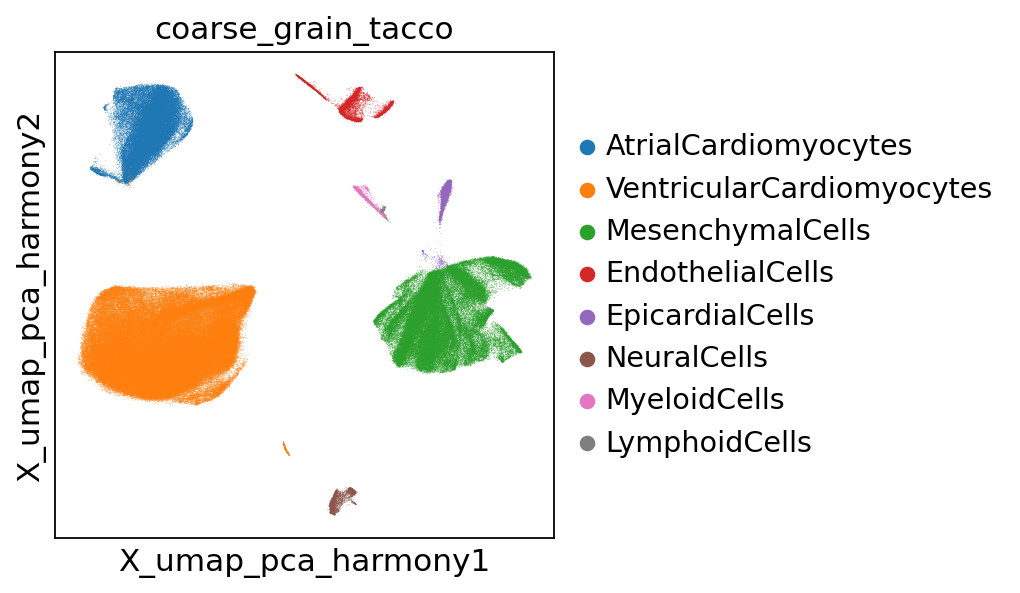

In [7]:
latent_space = 'pca_harmony'
sc.pl.embedding(adata,
                    basis=f"X_umap_{latent_space}",
                    color='coarse_grain_tacco',
                   )

In [8]:
adata.obs['coarse_grain_tacco'].value_counts()

coarse_grain_tacco
VentricularCardiomyocytes    174576
MesenchymalCells              86064
AtrialCardiomyocytes          50313
EndothelialCells              10891
EpicardialCells                4388
NeuralCells                    3626
MyeloidCells                   3126
LymphoidCells                   380
Name: count, dtype: int64

# Add fine-grained annotation

In [12]:
subset_adata_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium/TACCO/subsets'
fine_grain_colname = 'fine_grain_17Apr2026'

In [14]:
!ls -lh {subset_adata_dir}

total 1.5G
-rwxrwx---+ 1 kk837 kk837 374M Apr 17 23:33 AtrialCardiomyocytes_lognorm.h5ad
-rwxrwx---+ 1 kk837 kk837  88M Apr 17 15:24 EndothelialCells_lognorm.h5ad
-rwxrwx---+ 1 kk837 kk837  56M Apr 17 16:39 EpicardialCells_lognorm.h5ad
-rwxrwx---+ 1 kk837 kk837  29M Apr 17 16:47 LymphoidCells_lognorm.h5ad
-rwxrwx---+ 1 kk837 kk837 606M Apr 17 16:25 MesenchymalCells_lognorm.h5ad
-rwxrwx---+ 1 kk837 kk837  50M Apr 17 14:45 MyeloidCells_lognorm.h5ad
-rwxrwx---+ 1 kk837 kk837  52M Apr 16 06:19 NeuralCells_lognorm.h5ad
-rwxrwx---+ 1 kk837 kk837 1.3G Apr 16 11:28 VentricularCardiomyocytes_lognorm.h5ad


In [15]:
adata.obs[fine_grain_colname] =  adata.obs['celltypist_mid_fin'].astype('str').copy()

In [16]:
for celltype in set(adata.obs['coarse_grain_tacco']):
    print(celltype)
    ad = sc.read_h5ad(f'{subset_adata_dir}/{celltype}_lognorm.h5ad',backed='r')
    print(ad.shape)
    # add cell type labels
    adata.obs.loc[ad.obs_names,fine_grain_colname] = ad.obs['fine_grain_manual']
adata.obs[fine_grain_colname].value_counts()

EpicardialCells
(4388, 4387)
AtrialCardiomyocytes
(50313, 4998)
EndothelialCells
(10891, 4579)
NeuralCells
(3626, 4274)
LymphoidCells
(380, 3565)
MyeloidCells
(3126, 4306)
VentricularCardiomyocytes
(174576, 5001)
MesenchymalCells
(86064, 5000)


fine_grain_17Apr2026
LowCountsCells                        66066
Fibroblasts                           58914
VentricularCardiomyocytesCycling      56608
VentricularCardiomyocytes             48968
unclassified                          25568
AtrialCardiomyocytesRight             19866
AtrialCardiomyocytesCycling            7495
GreatVesselSmoothMuscleCells           6367
CoronaryPericytes                      5931
AtrialCardiomyocytesLeft               5830
SchwannCells                           4118
CoronaryVenousEndothelialCells         3298
LymphaticEndothelialCells              3013
MesothelialEpicardialCells             2989
EndocardialCells                       2308
AtrialCardiomyocytes_DoubletWithFB     1841
MacrophagesLYVE1pos                    1653
CoronarySmoothMuscleCells              1426
AtrioventricularNodePacemakerCells     1155
CoronaryCapillaryEndothelialCells      1120
DuctusArteriosusSmoothMuscleCells      1045
VentricularConductionSystemDistal      1029
Parasympath

# Add coarse-grained label

Need to modify followings
- VentricularConductionSystemDistal in AtrialCardiomyocytes
- ShwannCells in MesenchymalCells
- EndocardialCushionCells in EpicardialCells

In [23]:
coarse_grain_colname = 'coarse_grain_17Apr2026'
adata.obs[coarse_grain_colname] =  adata.obs['coarse_grain_tacco'].astype('str').copy()

In [24]:
##########
mask1 = adata.obs['coarse_grain_tacco']=='AtrialCardiomyocytes'
mask2 = adata.obs[fine_grain_colname]=='VentricularConductionSystemDistal'
obs_names = adata.obs_names[mask1&mask2].copy()
print(len(obs_names))
adata.obs.loc[obs_names,coarse_grain_colname] = 'VentricularCardiomyocytes'

##########
mask1 = adata.obs['coarse_grain_tacco']=='MesenchymalCells'
mask2 = adata.obs[fine_grain_colname]=='SchwannCells'
obs_names = adata.obs_names[mask1&mask2].copy()
print(len(obs_names))
adata.obs.loc[obs_names,coarse_grain_colname] = 'NeuralCells'

##########
mask1 = adata.obs['coarse_grain_tacco']=='EpicardialCells'
mask2 = adata.obs[fine_grain_colname]=='EndocardialCushionCells'
obs_names = adata.obs_names[mask1&mask2].copy()
print(len(obs_names))
adata.obs.loc[obs_names,coarse_grain_colname] = 'EndothelialCells'

1029
3364
93


In [25]:
pd.crosstab(adata.obs[fine_grain_colname],adata.obs[coarse_grain_colname])

coarse_grain_17Apr2026,AtrialCardiomyocytes,EndothelialCells,EpicardialCells,LymphoidCells,MesenchymalCells,MyeloidCells,NeuralCells,VentricularCardiomyocytes
fine_grain_17Apr2026,,,,,,,,
ArterialEndothelialCells,0,808,0,0,0,0,0,0
AtrialCardiomyocytesCycling,7495,0,0,0,0,0,0,0
AtrialCardiomyocytesLeft,5830,0,0,0,0,0,0,0
AtrialCardiomyocytesRight,19866,0,0,0,0,0,0,0
AtrialCardiomyocytesTransitional,812,0,0,0,0,0,0,0
AtrialCardiomyocytes_DoubletWithFB,1841,0,0,0,0,0,0,0
AtrioventricularNodePacemakerCells,1155,0,0,0,0,0,0,0
BCells,0,0,0,60,0,0,0,0
ChromaffinCells,0,0,0,0,0,0,159,0


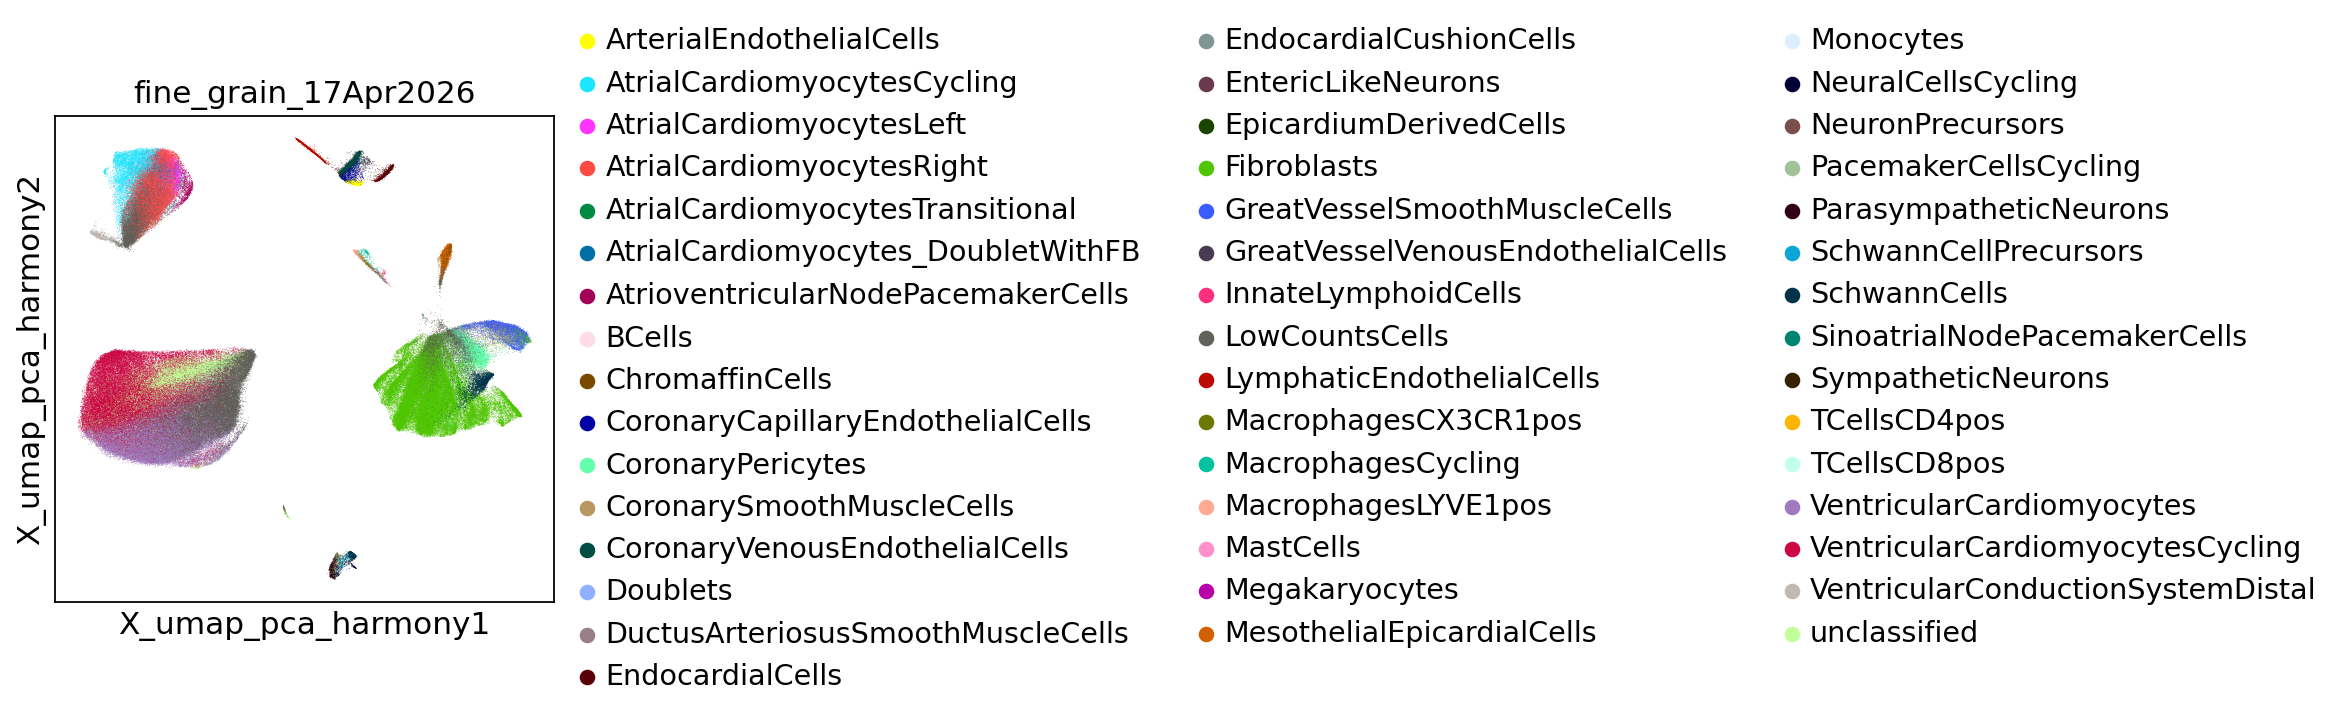

In [26]:
sc.pl.embedding(adata,
                    basis=f"X_umap_{latent_space}",
                    color=fine_grain_colname,
                   )

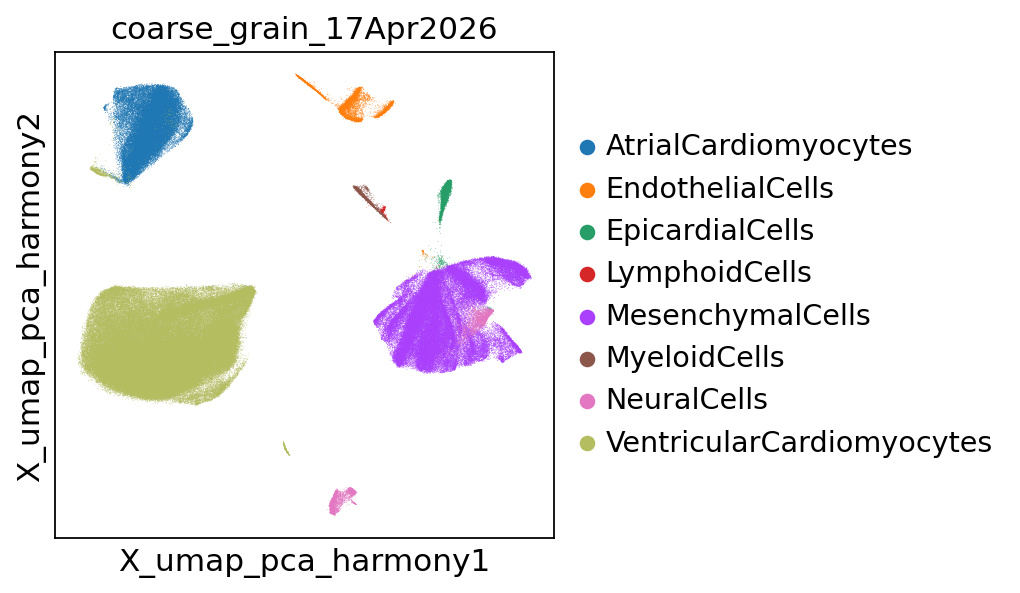

In [27]:
sc.pl.embedding(adata,
                    basis=f"X_umap_{latent_space}",
                    color=coarse_grain_colname,
                   )

# Save

In [28]:
adata.write(path_adata)
adata

AnnData object with n_obs × n_vars = 333364 × 5001
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'tissue_block_id', 'celltypist_coarse', 'conf_score_coarse', 'celltypist_coarse_fin', 'celltypist_coarse2midmod', 'conf_score_coarse2midmod', 'celltypist_mid_fin', 'celltypist_midmod2fine', 'conf_score_midmod2fine', 'pca_harmony_leiden_0.2', 'pca_harmony_leiden_0.3', 'pca_harmony_leiden_0.4', 'pca_harmony_leiden_0.5', 'pca_harmony_leiden_0.8', 'pca_harmony_leiden_1.0', 'pca_harmony_leiden_1.5', 'pca_harmony_leiden_2.0', 'pca_harmony_leiden_

In [29]:
path_adata

'/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium/TACCO/tacco-splitted_filtered_raw.h5ad'

# Save cell type-selected object

In [4]:
objects_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium'
path_adata = f'{objects_dir}/TACCO/tacco-splitted_filtered_raw.h5ad'
adata = sc.read_h5ad(path_adata)
adata.shape

(333364, 5001)

# Select cell types

In [6]:
celltype_sel = [
    'ArterialEndothelialCells',
     'AtrialCardiomyocytesCycling',
     'AtrialCardiomyocytesLeft',
     'AtrialCardiomyocytesRight',
     'AtrialCardiomyocytesTransitional',
     # 'AtrialCardiomyocytes_DoubletWithFB',
     'AtrioventricularNodePacemakerCells',
     'BCells',
     'ChromaffinCells',
     'CoronaryCapillaryEndothelialCells',
     'CoronaryPericytes',
     'CoronarySmoothMuscleCells',
     'CoronaryVenousEndothelialCells',
     # 'Doublets',
     'DuctusArteriosusSmoothMuscleCells',
     'EndocardialCells',
     'EndocardialCushionCells',
     # 'EntericLikeNeurons',
     'EpicardiumDerivedCells',
     'Fibroblasts',
     'GreatVesselSmoothMuscleCells',
     'GreatVesselVenousEndothelialCells',
     'InnateLymphoidCells',
     # 'LowCountsCells',
     'LymphaticEndothelialCells',
     'MacrophagesCX3CR1pos',
     'MacrophagesCycling',
     'MacrophagesLYVE1pos',
     'MastCells',
     # 'Megakaryocytes',
     'MesothelialEpicardialCells',
     'Monocytes',
     'NeuralCellsCycling',
     'NeuronPrecursors',
     'PacemakerCellsCycling',
     'ParasympatheticNeurons',
     'SchwannCellPrecursors',
     'SchwannCells',
     'SinoatrialNodePacemakerCells',
     'SympatheticNeurons',
     'TCellsCD4pos ',
     'TCellsCD8pos',
     'VentricularCardiomyocytes',
     'VentricularCardiomyocytesCycling',
     'VentricularConductionSystemDistal',
     # 'unclassified'
]

adata_sel = adata[adata.obs['fine_grain_17Apr2026'].isin(celltype_sel)]
adata_sel.shape

(239745, 5001)

In [7]:
# save
adata_sel.write(f'{objects_dir}/TACCO/tacco-splitted_filtered_celltype-sel_raw.h5ad')

# Output file for XeniumExplorer

In [9]:
fine_grain_colname = 'fine_grain_17Apr2026'

for tissue_id in ['C194-HEA-0-FFPE-1', 'Hst45-HEA-0-FFPE-1']:
    slide = adata_sel[adata_sel.obs['tissue_block_id']==tissue_id]
    df = slide.obs[['cell_id',fine_grain_colname]]
    df.columns = ['cell_id','group']
    df.to_csv(f'./{tissue_id}_cellgroup_XeniumExplorer_{fine_grain_colname}.csv',index=False)

# Plotting

In [10]:
# load original adata with spatial coordinates
adata_ori = sc.read_h5ad('/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/Xenium/C194-HEA-0-FFPE-1_Hst45-HEA-0-FFPE-1_concat_5K_filtered_celltype-sel_raw.h5ad',
                        backed='r')
adata.obsm['spatial'] = adata_ori[adata.obs_names].obsm['spatial'].copy()

/tmp/ipykernel_200386/4063734208.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=[fine_grain_colname],


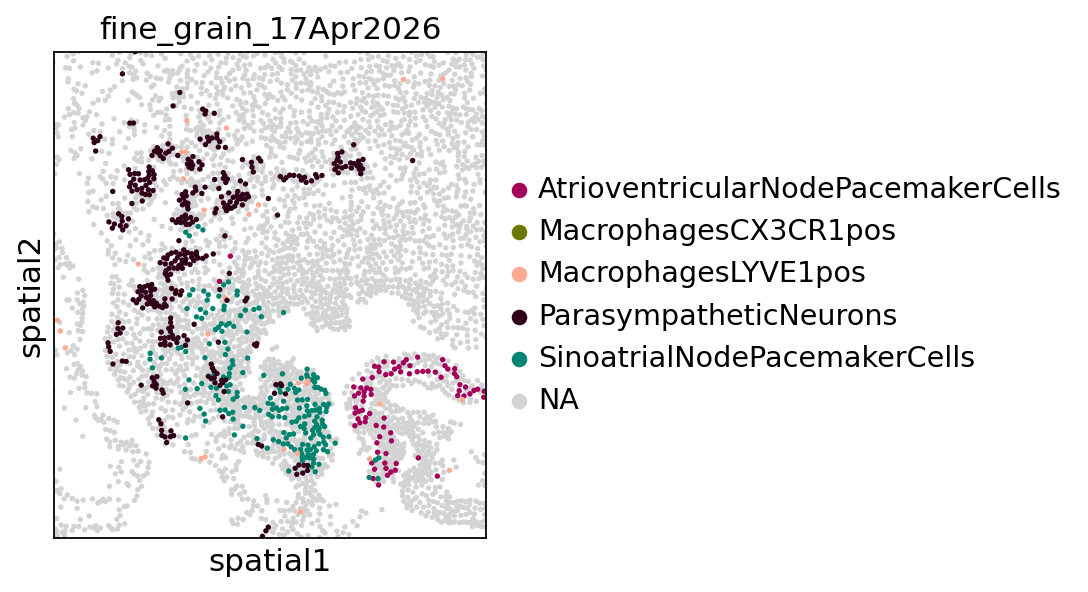

In [24]:
tissue_id = 'C194-HEA-0-FFPE-1'
slide = adata[adata.obs['tissue_block_id']==tissue_id]
sc.pl.spatial(slide,color=[fine_grain_colname],
              groups=['SinoatrialNodePacemakerCells','AtrioventricularNodePacemakerCells','ParasympatheticNeurons','MacrophagesCX3CR1pos','MacrophagesLYVE1pos'],
              spot_size=10,vmax='p100',
              crop_coord=(4800,5600,4200,5100)
             )

/tmp/ipykernel_200386/325364797.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=[fine_grain_colname],


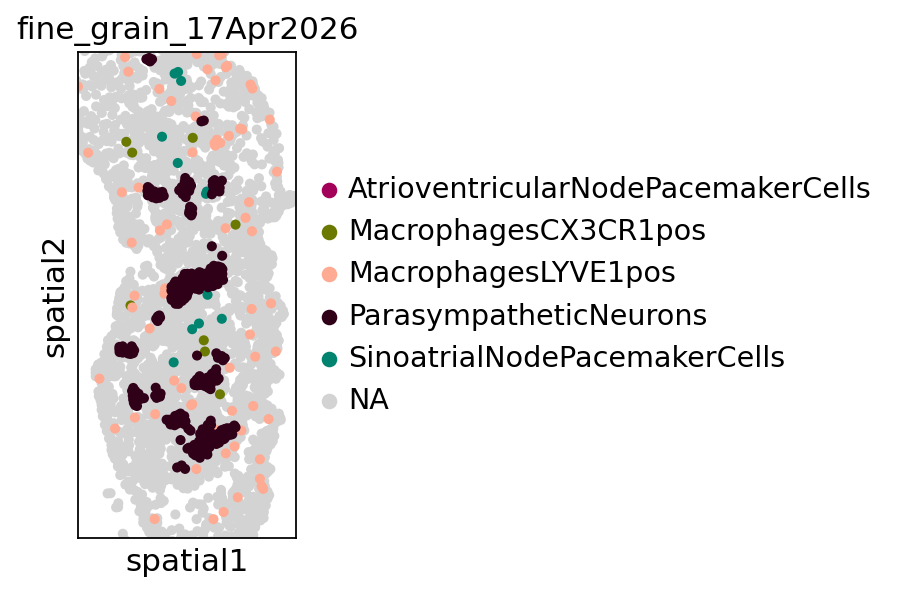

In [32]:
tissue_id = 'Hst45-HEA-0-FFPE-1'
slide = adata[adata.obs['tissue_block_id']==tissue_id]
sc.pl.spatial(slide,color=[fine_grain_colname],
              groups=['SinoatrialNodePacemakerCells','AtrioventricularNodePacemakerCells',
                      'ParasympatheticNeurons','MacrophagesCX3CR1pos','MacrophagesLYVE1pos'],
              spot_size=30,vmax='p100',
              crop_coord=(6300,6950,1250,2700)
             )

/tmp/ipykernel_200386/3177077215.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(slide,color=[fine_grain_colname],


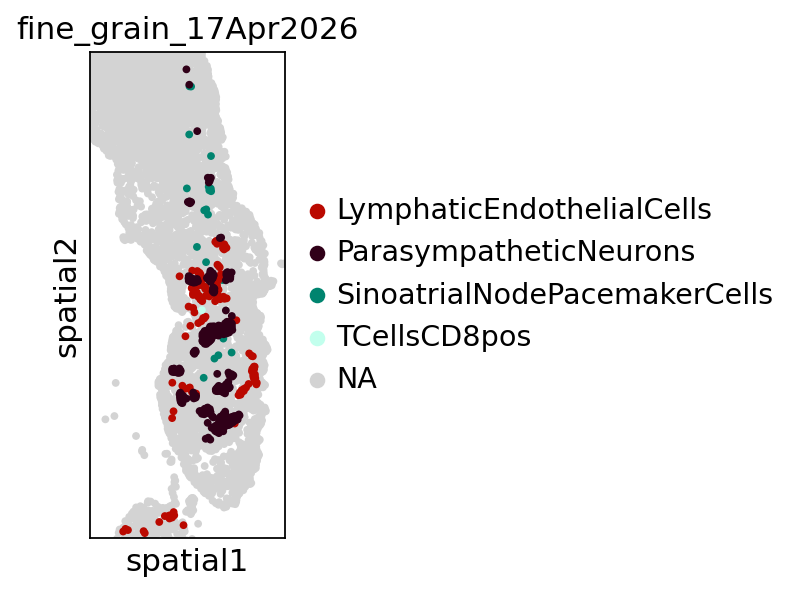

In [13]:
tissue_id = 'Hst45-HEA-0-FFPE-1'
slide = adata[adata.obs['tissue_block_id']==tissue_id]
sc.pl.spatial(slide,color=[fine_grain_colname],
              groups=['SinoatrialNodePacemakerCells','ParasympatheticNeurons','TCellsCD8pos','LymphaticEndothelialCells'],
              spot_size=40,vmax='p100',
              crop_coord=(6000,7000,500,3000)
             )

In [ ]:
for tissue_id in ['C194-HEA-0-FFPE-1', 'Hst45-HEA-0-FFPE-1']:
    slide = adata[adata.obs['tissue_block_id']==tissue_id]
    sc.pl.spatial(slide,color=[fine_grain_colname],
                  groups=['SinoatrialNodePacemakerCells','AtrioventricularNodePacemakerCells'],
                  spot_size=60,vmax='p100')

In [ ]:
for tissue_id in ['C194-HEA-0-FFPE-1', 'Hst45-HEA-0-FFPE-1']:
    slide = adata[adata.obs['tissue_block_id']==tissue_id]
    sc.pl.spatial(slide,color=[fine_grain_colname],
                  groups=['MacrophagesCX3CR1pos','MacrophagesLYVE1pos'],
                  spot_size=60,vmax='p100')

In [ ]:
for tissue_id in ['C194-HEA-0-FFPE-1', 'Hst45-HEA-0-FFPE-1']:
    slide = adata[adata.obs['tissue_block_id']==tissue_id]
    sc.pl.spatial(slide,color=[fine_grain_colname],
                  groups=['ParasympatheticNeurons','SympatheticNeurons','EntericLikeNeurons'],
                  spot_size=60,vmax='p100')

In [ ]:
for tissue_id in ['C194-HEA-0-FFPE-1', 'Hst45-HEA-0-FFPE-1']:
    slide = adata[adata.obs['tissue_block_id']==tissue_id]
    sc.pl.spatial(slide,color=[fine_grain_colname],
                  groups=['LymphoidCells'],
                  spot_size=60,vmax='p100')